In [1]:
# Data Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML Libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# config
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Data Science/Projects/Gradient Descent From Scratch/Salary_dataset.csv')

In [3]:
df.sample(5)

,Unnamed: 0,YearsExperience,Salary
6,6,3.1,60151.0
28,28,10.4,122392.0
27,27,9.7,112636.0
19,19,6.1,93941.0
15,15,5.0,67939.0


In [4]:
df = df.drop(columns = 'Unnamed: 0')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [40]:
X = df[['YearsExperience']]
y = df[['Salary']]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [41]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [42]:
y_pred = lr.predict(X_test)

In [135]:
print(lr.coef_)

[[9423.81532303]]


In [134]:
print(lr.intercept_)

[24380.20147947]


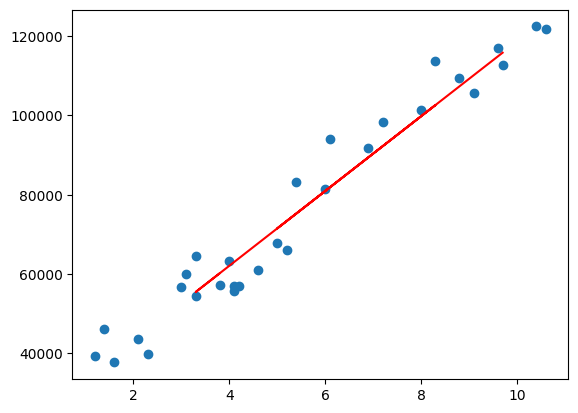

In [196]:
plt.scatter(X,y)
plt.plot(X_test,y_pred,color='red')
plt.show()

In [45]:
r2_score(y_pred, y_test)

0.8961838737587328

**Getting r2score = 0.89 After using Sk-learn**

In [169]:
class GDRegressorCF:
    def __init__(self, epochs, learning_rate):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.m = 0
        self.b = 0

    def fit(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()

        for i in range(self.epochs):
            y_pred = self.m * X + self.b
            loss_slope_m = -2 * np.sum((y - y_pred) * X)
            loss_slope_b = -2 * np.sum(y - y_pred)

            self.m = self.m - self.learning_rate * loss_slope_m
            self.b = self.b - self.learning_rate * loss_slope_b



    def predict(self, X):
        X = np.array(X).flatten()
        return self.m * X + self.b




In [191]:
gdr = GDRegressorCF(100, 0.001)

In [192]:
gdr.fit(X_train, y_train)

In [193]:
y_pred1 = gdr.predict(X_test)

In [194]:
r2_score(y_test,y_pred1)

0.8729250692486171

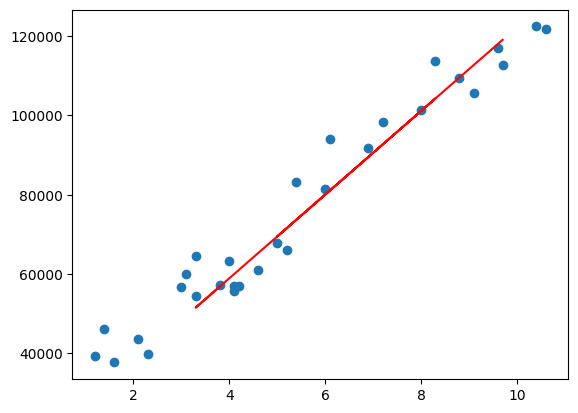

In [198]:
plt.scatter(X,y)
plt.plot(X_test,y_pred1,color='red')
plt.show()